# Import necessary libraries

In [15]:
import pandas as pd
import sqlite3

# Step 1: Data Extraction

In [28]:
# Load CSV files into pandas DataFrames
product_df = pd.read_csv('/content/final_product.csv')
sales_df = pd.read_csv('/content/final_sales.csv')
reviews_df = pd.read_csv('/content/final_reviews.csv')

# Step 2: Data Transformation

##HANDLING MISSING VALUES

###HANDLING MISSING VALUES IN SALES DATA

In [29]:
# Handle missing values

# Fill 'Region' with the most common (mode) value across all records
sales_df['Region'] = sales_df['Region'].fillna(sales_df['Region'].mode()[0])

# Fill 'Manager' with forward fill method based on previous non-null values
sales_df['Manager'] = sales_df['Manager'].ffill()

# Fill 'SalesMan' based on the most common SalesMan within each Manager
sales_df['SalesMan'] = sales_df.groupby('Manager')['SalesMan'].transform(lambda x: x.ffill().bfill())

# Fill 'Item' with a placeholder for missing values
sales_df['Item'] = sales_df['Item'].fillna("Unknown Item")

# Fill 'Units' with the median Units within each Item
sales_df['Units'] = sales_df.groupby('Item')['Units'].transform(lambda x: x.fillna(x.median()))

# Fill 'Unit_price' with the median Unit_price within each Item
sales_df['Unit_price'] = sales_df.groupby('Item')['Unit_price'].transform(lambda x: x.fillna(x.median()))

# Calculate 'Sale_amt' as Units * Unit_price if Sale_amt is missing
sales_df['Sale_amt'] = sales_df.apply(lambda row: row['Units'] * row['Unit_price'] if pd.isnull(row['Sale_amt']) else row['Sale_amt'], axis=1)

# Display the updated DataFrame
sales_df.head()


,Region,Manager,SalesMan,Item,Units,Unit_price,Sale_amt,Product_ID,Sale_ID
0,East,Hina,Shoaib,Cartoon Cat Printing Student School Bags Women...,95.0,94,8930,7eba5a29-2cfb-46a8-a324-d1d89342b7be,5658fdc7
1,Central,Tariq,Rabia,Animal Prints Cotton Canvas Children Bags Back...,50.0,155,7750,7e7bea92-3537-40c4-af7f-39d60b3591f2,adf487fe
2,Central,Hussain,Fatima,"Night Vision Car, Biking & Cycling Sunglasses",36.0,15900,572400,71a25ac6-c830-4418-9035-ec7fc6da4e83,e5bb2400
3,Central,Zain,Sana,1 Pis Waterproof And Long Lasting Tire Marking...,27.0,99,2673,8a0794e8-ac2f-44d7-84c0-c8816abe28ad,a993c47a
4,West,Ayesha,Nazia,MISSHA Airy Fit Sheet Mask Pearl,56.0,165,9240,5c219cda-58aa-4a1a-8029-2ce870cf31e0,f9e18d93


###HANDLING MISSING VALUES IN PRODUCTS DATA

In [30]:
# Handle missing values for numerical columns using median
product_df['DiscountedPrice'] = product_df['DiscountedPrice'].fillna(product_df['DiscountedPrice'].median())
product_df['Discount'] = product_df['Discount'].fillna(product_df['Discount'].median())
product_df['NumberofRatings'] = product_df['NumberofRatings'].fillna(product_df['NumberofRatings'].median())

# Fill missing 'SellerName' and 'DeliveryType' categorical columns with forward fill or a default value
product_df['SellerName'] = product_df['SellerName'].ffill()
product_df['DeliveryType'] = product_df['DeliveryType'].fillna('Standard Delivery')

# Calculate 'Discount' if it's missing and can be derived from 'OriginalPrice' and 'DiscountedPrice'
product_df['Discount'] = product_df.apply(
    lambda row: ((row['OriginalPrice'] - row['DiscountedPrice']) / row['OriginalPrice'] * 100)
    if pd.isnull(row['Discount']) and pd.notnull(row['DiscountedPrice']) else row['Discount'], axis=1)

# Fill missing 'ProductToBeSold' with a placeholder
product_df['ProductToBeSold'] = product_df['ProductToBeSold'].fillna("Not Specified")

# Handle missing values in 'SubCategory' using forward fill
product_df['SubCategory'] = product_df['SubCategory'].ffill()

product_df['ShipOnTime'] = product_df['ShipOnTime'].apply(lambda x: "No" if x == 0 else "Yes")


# Display the updated DataFrame
product_df.head()

,Category,SubCategory,Title,OriginalPrice,DiscountedPrice,Discount,SellerName,NumberofRatings,PositiveSellerRatings,ShipOnTime,ChatResponseRate,DeliveryType,ProductToBeSold,SellPercentageToIncrease,Product_ID
0,"Watches, Bags, Jewellery",Kids Bags,Animal Prints Cotton Canvas Children Bags Back...,550,255,54.0,Twenty Twenty,342,85,No,98,Standard Delivery,107.84,116,7eba5a29-2cfb-46a8-a324-d1d89342b7be
1,"Watches, Bags, Jewellery",Kids Bags,School Bags For Girls Big Capacity Backpack Sh...,1650,725,56.0,AYSHA TRADERS,31,86,No,93,Free Delivery,113.79,128,7e7bea92-3537-40c4-af7f-39d60b3591f2
2,"Watches, Bags, Jewellery",Kids Bags,Nylon Animal Children Backpacks Kids Preschool...,350,195,44.0,Shah Wholesale Fashion,13,77,No,57,Free Delivery,89.74,80,71a25ac6-c830-4418-9035-ec7fc6da4e83
3,"Watches, Bags, Jewellery",Kids Bags,Backpacks for kids in kindergarten Cute baby b...,1200,749,38.0,Ghoredokanbd,23,93,No,100,Standard Delivery,80.11,61,8a0794e8-ac2f-44d7-84c0-c8816abe28ad
4,"Watches, Bags, Jewellery",Kids Bags,kids bag toddler backpack with leash messenger...,350,286,18.0,Darun Online Shop,3,90,No,100,Free Delivery,61.19,23,5c219cda-58aa-4a1a-8029-2ce870cf31e0


###HANDLING MISSING VALUES IN REVIEWS DATA

In [31]:

# Fill missing values for Product_ID and Customer_ID by forward filling (if grouped by Product_ID)
reviews_df['Product_ID'] = reviews_df['Product_ID'].ffill()
reviews_df['Customer_ID'] = reviews_df['Customer_ID'].ffill()

# Fill missing values for Customer_Name by forward filling or setting to 'Anonymous' if Customer_ID is unique
reviews_df['Customer_Name'] = reviews_df['Customer_Name'].fillna('Anonymous')

# Fill missing values for Date by forward filling
reviews_df['Date'] = reviews_df['Date'].ffill()

# Fill missing values for Rating with the average rating or drop rows with missing values
reviews_df['Rating'] = reviews_df['Rating'].fillna(reviews_df['Rating'].mean())

# Fill missing values for Sentiment with a placeholder like 'Unknown' if necessary
reviews_df['Sentiment'] = reviews_df['Sentiment'].fillna('Unknown')

# Fill missing Reviews with "No Review" if a review is missing
reviews_df['Reviews'] = reviews_df['Reviews'].fillna('No Review')


# Display the updated DataFrame
reviews_df.head()

,Product_ID,Customer_Name,Customer_ID,Date,Rating,Reviews,Sentiment,Review_ID
0,7eba5a29-2cfb-46a8-a324-d1d89342b7be,itzmr7,6702,11/9/2019,1,mil gya hai acha hai aur toota howa b nai hai,Positive,6bcb8260
1,7e7bea92-3537-40c4-af7f-39d60b3591f2,Afridi,396,11/21/2016,5,aram sy pocket may aa jta hai aur quality b ac...,Positive,ab917946
2,71a25ac6-c830-4418-9035-ec7fc6da4e83,Muhammed,3710,10/22/2018,2,sb sy achi chez apki customer service bhot ach...,Positive,c681d16e
3,8a0794e8-ac2f-44d7-84c0-c8816abe28ad,Ghazanfar,1860,10/6/2017,3,back cover acha hai sai cuts hai aur soft b ha...,Positive,a38641cf
4,5c219cda-58aa-4a1a-8029-2ce870cf31e0,Murtaza iqbal,3778,8/31/2017,4,shru may may thumb grip k khalif thi kyu k ext...,Negative,0232e8d3


###VERIFYING THERE ARE NO MISSING VALUES

In [32]:
# Check for missing values
missing_values = reviews_df.isnull().sum()

# Print missing values for each column
print("Reviews Table")
print("Missing values in each column :")
print(missing_values)

# Alternatively, print only columns with missing values
print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

# Check for missing values
missing_values = product_df.isnull().sum()

# Print missing values for each column
print("Products Table")
print("Missing values in each column :")
print(missing_values)

# Alternatively, print only columns with missing values
print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

# Check for missing values
missing_values = sales_df.isnull().sum()

# Print missing values for each column
print("Sales Table")
print("Missing values in each column :")
print(missing_values)

# Alternatively, print only columns with missing values
print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Reviews Table
Missing values in each column :
Product_ID       0
Customer_Name    0
Customer_ID      0
Date             0
Rating           0
Reviews          0
Sentiment        0
Review_ID        0
dtype: int64

Columns with missing values:
Series([], dtype: int64)
Products Table
Missing values in each column :
Category                    0
SubCategory                 0
Title                       0
OriginalPrice               0
DiscountedPrice             0
Discount                    0
SellerName                  0
NumberofRatings             0
PositiveSellerRatings       0
ShipOnTime                  0
ChatResponseRate            0
DeliveryType                0
ProductToBeSold             0
SellPercentageToIncrease    0
Product_ID                  0
dtype: int64

Columns with missing values:
Series([], dtype: int64)
Sales Table
Missing values in each column :
Region        0
Manager       0
SalesMan      0
Item          0
Units         0
Unit_price    0
Sale_amt      0
Product_ID   

##REMOVING DUPLICATES

In [34]:
# Remove duplicates based on specific ID columns
reviews_df = reviews_df.drop_duplicates(subset='Review_ID', keep='first')
sales_df = sales_df.drop_duplicates(subset='Sale_ID', keep='first')
products_df = product_df.drop_duplicates(subset='Product_ID', keep='first')


##STORING CLEANED TRANSFORMED DATA INTO DIFFERENT CSV FILES

In [35]:
# Save cleaned data back to CSV files
reviews_df.to_csv('Cleaned_Reviews.csv', index=False)
sales_df.to_csv('Cleaned_Sales.csv', index=False)
products_df.to_csv('Cleaned_Products.csv', index=False)

# Step 3: Denormalization (Combine tables based on relationships, e.g., Sales with Product info)

In [36]:
# Merge Product and Sales tables using Product_ID as the PK-FK relationship
product_sales_df = pd.merge(sales_df, product_df, left_on='Product_ID', right_on='Product_ID', how='left')

# Merge Product and Reviews tables using Product_ID as the PK-FK relationship
product_reviews_df = pd.merge(reviews_df, product_df, left_on='Product_ID', right_on='Product_ID', how='left')



# Step 4: Load Data into SQLite Database

In [51]:
# Connect to SQLite database (create or open existing)
conn = sqlite3.connect('project_database.db')
cursor = conn.cursor()

# Load individual tables
product_df.to_sql('Product', conn, if_exists='replace', index=False)
sales_df.to_sql('Sales', conn, if_exists='replace', index=False)
reviews_df.to_sql('Reviews', conn, if_exists='replace', index=False)

# Load denormalized tables
product_sales_df.to_sql('Product_Sales', conn, if_exists='replace', index=False)
product_reviews_df.to_sql('Product_Reviews', conn, if_exists='replace', index=False)

# Confirm data insertion
for table in ['Product', 'Sales', 'Reviews', 'Product_Sales', 'Product_Reviews']:
    print(f"\nTable: {table}")
    print(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn))

# Step 5: Export Final Database with Complete Values
conn.commit()  # Save changes
conn.close()  # Close connection

# Export to CSV for backup if needed
product_df.to_csv('Product_Final.csv', index=False)
sales_df.to_csv('Sales_Final.csv', index=False)
reviews_df.to_csv('Reviews_Final.csv', index=False)
product_sales_df.to_csv('Product_Sales_Final.csv', index=False)
product_reviews_df.to_csv('Product_Reviews_Final.csv', index=False)

print("ETL process completed successfully!")


Table: Product
                   Category SubCategory  \
0  Watches, Bags, Jewellery   Kids Bags   
1  Watches, Bags, Jewellery   Kids Bags   
2  Watches, Bags, Jewellery   Kids Bags   
3  Watches, Bags, Jewellery   Kids Bags   
4  Watches, Bags, Jewellery   Kids Bags   

                                               Title  OriginalPrice  \
0  Animal Prints Cotton Canvas Children Bags Back...            550   
1  School Bags For Girls Big Capacity Backpack Sh...           1650   
2  Nylon Animal Children Backpacks Kids Preschool...            350   
3  Backpacks for kids in kindergarten Cute baby b...           1200   
4  kids bag toddler backpack with leash messenger...            350   

   DiscountedPrice  Discount              SellerName  NumberofRatings  \
0              255      54.0           Twenty Twenty              342   
1              725      56.0           AYSHA TRADERS               31   
2              195      44.0  Shah Wholesale Fashion               13   
3     

# Step 5: ROLAP query for comprehensive Power BI analysis





In [38]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect('project_database.db')

# Define the ROLAP query for comprehensive Power BI analysis
query = """
SELECT
    -- Product Details
    p.Category,
    p.SubCategory,
    p.Title AS Product_Title,
    p.OriginalPrice,
    p.DiscountedPrice,
    p.Discount,
    p.SellerName,
    p.NumberofRatings,
    p.PositiveSellerRatings,
    p.ShipOnTime,
    p.ChatResponseRate,
    p.DeliveryType,
    p.ProductToBeSold,
    p.SellPercentageToIncrease,

    -- Sales Details
    s.Region,
    s.Manager,
    s.Salesman,
    s.Units,
    s.Unit_price,
    s.Sale_amt,

    -- Additional Calculations
    (p.OriginalPrice - p.DiscountedPrice) AS Price_Difference,
    ((p.OriginalPrice - p.DiscountedPrice) / p.OriginalPrice * 100) AS Discount_Percentage,
    (s.Units * s.Unit_price) AS Total_Sale_Value,

    -- Review Details
    r.Customer_Name,
    r.Customer_ID,
    r.Date,
    r.Rating,
    r.Reviews,
    r.Sentiment

FROM
    Product AS p
LEFT JOIN
    Sales AS s ON p.Title = s.Item
LEFT JOIN
    Reviews AS r ON p.Title = r.Product_ID
"""

# Execute query and load result into a DataFrame
df_result = pd.read_sql(query, conn)

# Save result to CSV for Power BI import
df_result.to_csv('ROLAP_data_for_PowerBI.csv', index=False)

# Close database connection
conn.close()

print("ROLAP query executed and results saved to 'ROLAP_data_for_PowerBI.csv'")


ROLAP query executed and results saved to 'ROLAP_data_for_PowerBI.csv'


# Step: 6 Graph Illustrations through Matplotlib

<ipython-input-39-501b0a497f14>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette="viridis")


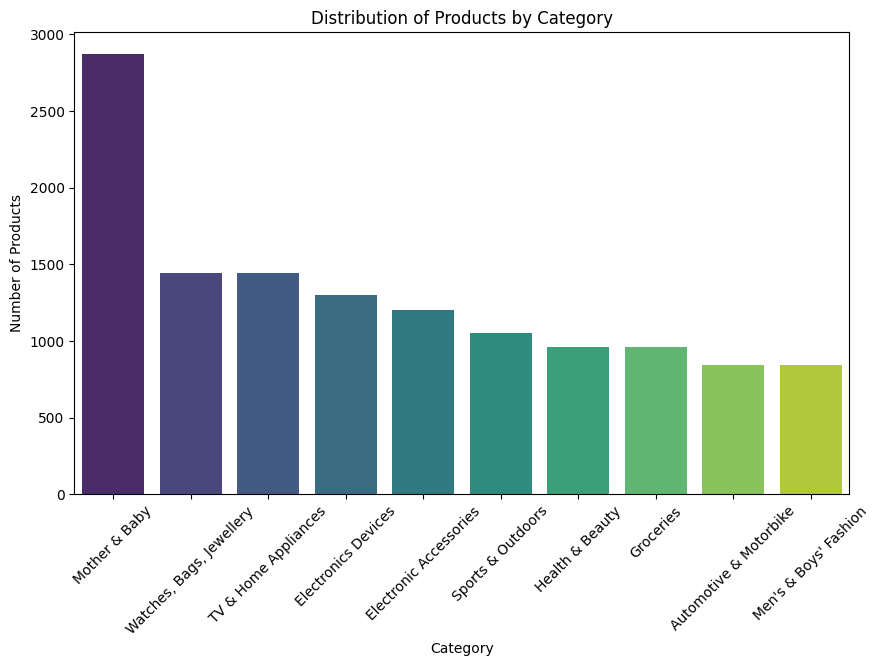

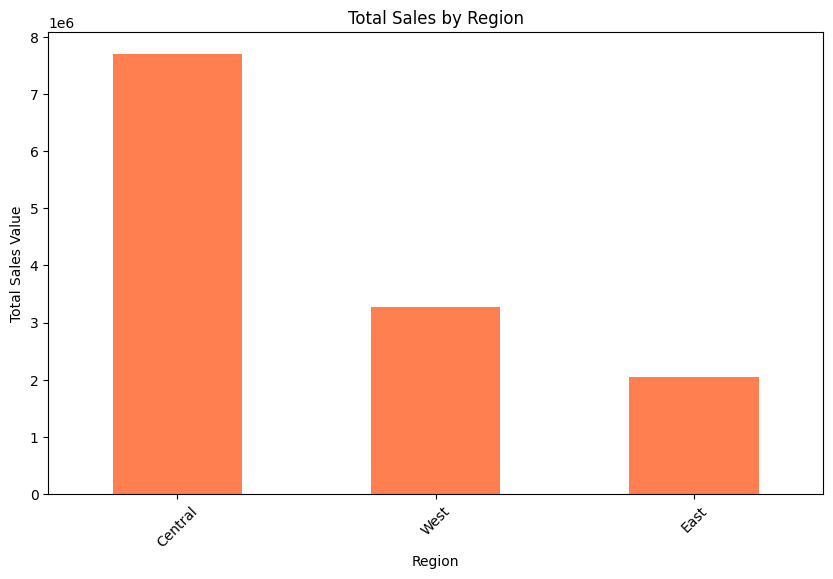

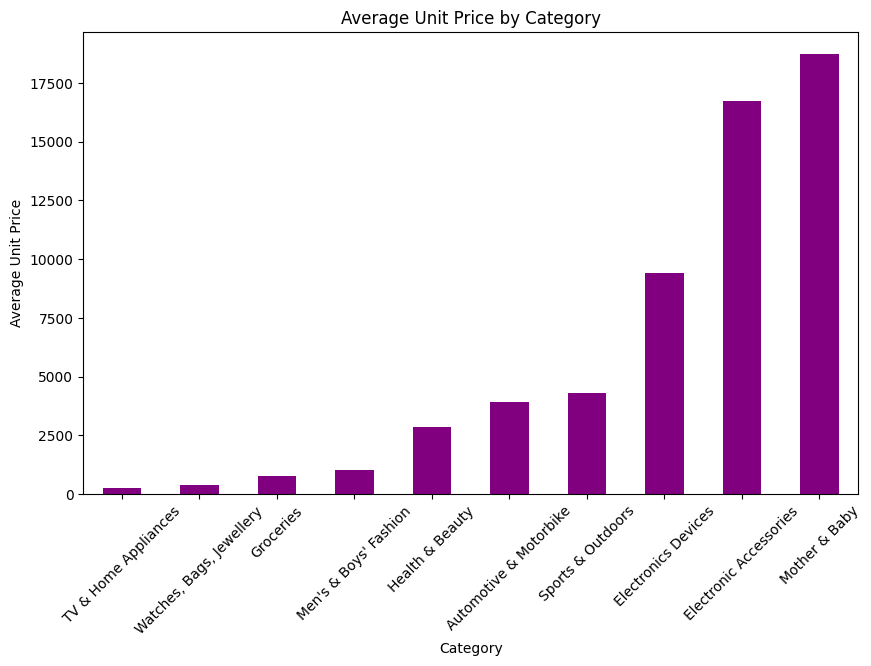

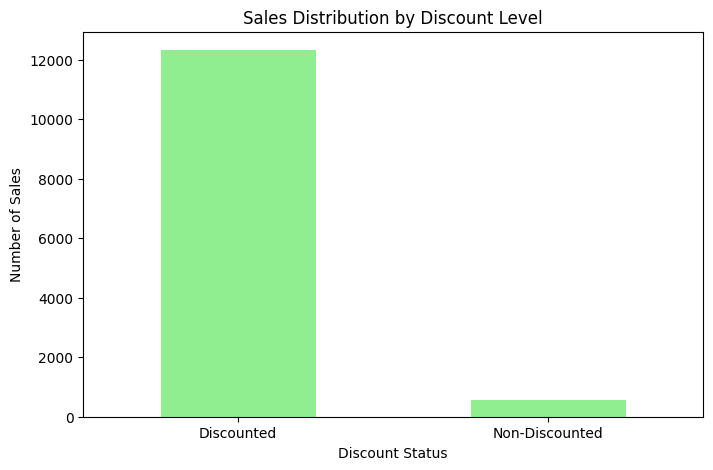

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the ROLAP data into a DataFrame
df = pd.read_csv('ROLAP_data_for_PowerBI.csv')

# Count of Products by Category
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette="viridis")
plt.title('Distribution of Products by Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

# Total Sales by Region
region_sales = df.groupby('Region')['Total_Sale_Value'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar', color='coral')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=45)
plt.show()

# Average Unit Price by Category
avg_price_category = df.groupby('Category')['Unit_price'].mean().sort_values()
plt.figure(figsize=(10, 6))
avg_price_category.plot(kind='bar', color='purple')
plt.title('Average Unit Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Unit Price')
plt.xticks(rotation=45)
plt.show()

# Creating a new column for Discounted vs Non-Discounted
df['Discounted'] = df['Discount'].fillna(0).apply(lambda x: 'Discounted' if x > 0 else 'Non-Discounted')

# Sales Distribution by Discount Level
discount_sales_count = df['Discounted'].value_counts()
plt.figure(figsize=(8, 5))
discount_sales_count.plot(kind='bar', color='lightgreen')
plt.title('Sales Distribution by Discount Level')
plt.xlabel('Discount Status')
plt.ylabel('Number of Sales')
plt.xticks(rotation=0)
plt.show()




#Step 7 Data Mining

# Clustering Products (K-Means)

###Use Case: Analyze products for pricing, seller performance, and sales improvement.
Technique used


 Clustering: Identify groups of similar
products based on price, discount, and seller ratings. For example, cluster products into budget, mid-range, and premium categories.


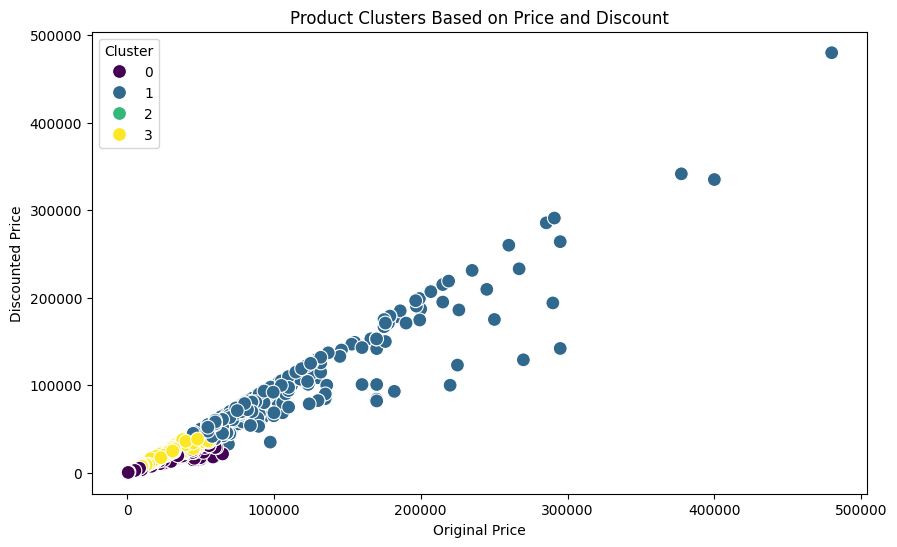

Cluster 0 Summary:


,OriginalPrice,DiscountedPrice,Discount,NumberofRatings,PositiveSellerRatings,ChatResponseRate,ProductToBeSold,SellPercentageToIncrease,Cluster
count,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.0
mean,1557.315347,761.864356,53.292409,68.521122,78.115677,88.888449,118.962749,138.403300,0.0
std,4312.164385,2153.897779,12.074532,130.620771,22.705691,22.146411,65.830564,131.657712,0.0
min,31.000000,5.000000,35.000000,0.000000,0.000000,0.000000,25.000000,-50.000000,0.0
25%,290.000000,122.000000,43.000000,3.000000,80.000000,90.000000,87.947500,76.000000,0.0
50%,599.000000,269.000000,51.000000,18.000000,84.000000,98.000000,103.075000,107.000000,0.0
75%,1250.000000,576.000000,61.000000,68.000000,88.000000,100.000000,129.212500,159.000000,0.0
max,65000.000000,30920.000000,98.000000,921.000000,100.000000,100.000000,2495.450000,4891.000000,0.0


Cluster 1 Summary:


,OriginalPrice,DiscountedPrice,Discount,NumberofRatings,PositiveSellerRatings,ChatResponseRate,ProductToBeSold,SellPercentageToIncrease,Cluster
count,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.0
mean,90743.557692,80060.613248,10.957051,3.905983,78.790598,87.675214,57.342479,15.096154,1.0
std,54331.584049,48632.553535,11.044262,17.831706,26.709776,25.403242,9.968372,19.965424,0.0
min,45000.000000,32640.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,1.0
25%,58000.000000,52336.000000,4.000000,0.000000,81.000000,92.000000,52.067500,5.000000,1.0
50%,72490.000000,64995.000000,8.000000,0.000000,88.000000,98.000000,54.350000,9.000000,1.0
75%,98000.000000,87780.750000,14.000000,1.000000,92.000000,100.000000,58.472500,17.000000,1.0
max,479900.000000,479900.000000,64.000000,279.000000,100.000000,100.000000,139.330000,179.000000,1.0


Cluster 2 Summary:


,OriginalPrice,DiscountedPrice,Discount,NumberofRatings,PositiveSellerRatings,ChatResponseRate,ProductToBeSold,SellPercentageToIncrease,Cluster
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.0
mean,652.887097,344.540323,38.459677,1706.858871,86.459677,90.895161,107.906250,116.294355,2.0
std,694.971082,418.962424,24.815725,1263.638167,6.910532,15.367202,82.828315,165.651988,0.0
min,10.000000,9.000000,2.000000,890.000000,0.000000,0.000000,51.140000,3.000000,2.0
25%,192.500000,123.750000,14.750000,1052.500000,85.000000,93.750000,58.617500,17.750000,2.0
50%,360.000000,187.000000,38.000000,1290.000000,89.000000,96.000000,80.460000,61.500000,2.0
75%,892.250000,374.250000,58.000000,1799.750000,89.000000,98.000000,119.202500,139.250000,2.0
max,3990.000000,3700.000000,89.000000,11914.000000,96.000000,100.000000,471.010000,843.000000,2.0


Cluster 3 Summary:


,OriginalPrice,DiscountedPrice,Discount,NumberofRatings,PositiveSellerRatings,ChatResponseRate,ProductToBeSold,SellPercentageToIncrease,Cluster
count,6131.000000,6131.000000,6131.000000,6131.000000,6131.000000,6131.000000,6131.000000,6131.000000,6131.0
mean,4101.467624,3406.781602,18.297765,54.473006,80.656989,89.134562,62.291866,25.032947,3.0
std,9342.917372,7814.638927,10.965788,118.033715,22.763733,21.941781,8.407712,16.853139,0.0
min,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,19.000000,-62.000000,3.0
25%,240.000000,188.000000,9.000000,1.000000,83.000000,92.000000,55.050000,11.000000,3.0
50%,600.000000,494.000000,19.000000,9.000000,88.000000,97.000000,61.600000,24.000000,3.0
75%,2000.000000,1601.000000,28.000000,49.000000,89.000000,100.000000,69.525000,40.000000,3.0
max,56000.000000,43500.000000,40.000000,945.000000,100.000000,100.000000,83.530000,68.000000,3.0


In [41]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the dataset
product_df = pd.read_csv('/content/Product_Final.csv')

# Select relevant numerical features for clustering
features = ['OriginalPrice', 'DiscountedPrice', 'Discount', 'NumberofRatings']
product_data = product_df[features]

# Normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(product_data)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
product_df['Cluster'] = kmeans.fit_predict(scaled_data)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=product_df, x='OriginalPrice', y='DiscountedPrice', hue='Cluster', palette='viridis', s=100)
plt.title('Product Clusters Based on Price and Discount')
plt.xlabel('Original Price')
plt.ylabel('Discounted Price')
plt.legend(title='Cluster')
plt.show()

# Display detailed report
for cluster in sorted(product_df['Cluster'].unique()):
    print(f"Cluster {cluster} Summary:")
    display(product_df[product_df['Cluster'] == cluster].describe())


Cluster 0: Mid-Priced, Moderate Discounts, Average Ratings
Key Characteristics:

Average Original Price: 1,557 with a wide range (31 to 65,000).
Average Discount: ~53%, indicating moderate discounting.
Moderate Number of Ratings: ~68, but skewed due to high variability (up to 921 ratings for some products).
Moderate Positive Seller Ratings: ~78%.
Relatively high sales expectations: Mean ProductToBeSold is 118.96.
Cluster Size: Largest cluster with 6,060 products.
Interpretation: Cluster 0 likely includes mid-range products with moderate discounts and a decent number of ratings. These products may appeal to a broad audience and have reasonable sales potential.

Cluster 1: High-Priced, Minimal Discounts, Low Ratings
Key Characteristics:

Average Original Price: 90,743 (very expensive, with some products priced up to 479,900).
Average Discount: 10.9%, indicating minimal discounts.
Very low Number of Ratings: Mean of 3.9, suggesting low customer engagement or visibility.
Decent Positive Seller Ratings: ~78.7%.
Low sales expectations: ProductToBeSold mean is 57.34.
Cluster Size: Smallest cluster with 468 products.
Interpretation: Cluster 1 represents premium, high-priced products with minimal discounts and low customer interaction. These items may target niche or luxury markets with limited sales volume.



Cluster 2: Low-Priced, High Volume, High Discounts
Key Characteristics:

Average Original Price: ~653, with low prices ranging from 10 to 3,990.
Average Discount: ~38%, with some products discounted up to 89%.
Extremely high Number of Ratings: Mean of 1,706, suggesting very popular products.
High Positive Seller Ratings: ~86.4%.
High sales expectations: ProductToBeSold mean of 107.91, with potential outliers.
Cluster Size: Small cluster with 248 products.
Interpretation: Cluster 2 includes highly affordable, heavily discounted products with high customer engagement. These are popular, high-volume items likely driving significant sales.

Cluster 3: Moderate-Priced, Low Volume, Moderate Discounts
Key Characteristics:

Average Original Price: ~4,101 (mid-to-high range).
Average Discount: 18.3%, indicating moderate discounting.
Low Number of Ratings: ~54, showing low customer engagement.
Good Positive Seller Ratings: ~80.7%.
Moderate sales expectations: Mean ProductToBeSold is 62.29.
Cluster Size: Large cluster with 6,131 products.
Interpretation: Cluster 3 consists of moderately priced, less-discounted products with relatively low ratings. These are likely less popular items that may need better marketing or incentives to boost visibility and sales.



 # Sentiment Classification Using Naive Bayes

##Use Case: Understand customer feedback and sentiment.

> Add blockquote



Techniques:
Classification: Use the "Sentiment" column to train a model for predicting sentiment (positive/negative) based on reviews.

Class-by-Class Breakdown

Class 0 (Negative):

Precision (61%): 61% of predictions labeled as "Negative" were correct.
Recall (56%): 56% of the actual "Negative" instances were correctly identified.
F1-Score (58%): A balance of precision and recall for "Negative" predictions.

Class 1 (Positive):

Precision (75%): 76% of predictions labeled as "Positive" were correct.
Recall (89%): 90% of the actual "Positive" instances were correctly identified.
F1-Score (82%): Strong overall performance in identifying "Positive" sentiment.

Class 2 (Neutral):

Precision (48%): 48% of predictions labeled as "Neutral" were correct.
Recall (22%): Only 22% of actual "Neutral" instances were correctly identified.
F1-Score (30%): Poor performance for this class due to low recall.

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.56      0.58       293
           1       0.75      0.89      0.82       706
           2       0.47      0.20      0.28       178

    accuracy                           0.70      1177
   macro avg       0.61      0.55      0.56      1177
weighted avg       0.67      0.70      0.68      1177



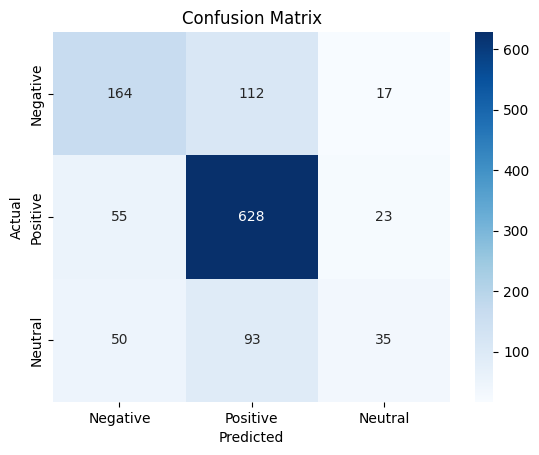

Accuracy: 0.70


In [60]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt  # Importing pyplot for plotting

# Hardcoded stopwords for English
hardcoded_english_stopwords = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which",
    "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be",
    "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by",
    "for", "with", "about", "against", "between", "into", "through", "during", "before", "after",
    "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under",
    "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all",
    "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not",
    "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just",
    "don", "should", "now"
}

# Re-define Roman Urdu stopwords
roman_urdu_stopwords = {"hai", "ka", "ki", "kaun", "aur", "kya", "kyun", "nahi", "acha", "to"}

# Combine English and Roman Urdu stopwords
combined_stopwords = hardcoded_english_stopwords.union(roman_urdu_stopwords)

# Load the dataset
reviews_df = pd.read_csv('/content/Reviews_Final.csv')

# Define a text preprocessing function
def preprocess_text(text):
    # Lowercase the text
    text = text.lower()
    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in combined_stopwords])
    return text

# Apply preprocessing to reviews
reviews_df['Cleaned_Reviews'] = reviews_df['Reviews'].apply(preprocess_text)

# Map Sentiment to numeric values
y = reviews_df['Sentiment'].map({'Positive': 1, 'Negative': 0, 'Neutral': 2})

# Initialize CountVectorizer for cleaned text data
vectorizer = CountVectorizer()

# Transform cleaned reviews into feature vectors
X = vectorizer.fit_transform(reviews_df['Cleaned_Reviews'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive', 'Neutral'],
            yticklabels=['Negative', 'Positive', 'Neutral'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print accuracy score
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


